# Device Parameter Sweep Pilot

This notebook runs a small controlled sweep for the SolarLab band-alignment, doping, absorber-defect, and interface-recombination studies. It keeps the existing solver, initial-condition path, and boundary-condition model unchanged; each row only changes the input material/interface parameters before calling `run_jv_sweep` through the reusable sweep module.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt

from perovskite_sim.sweeps.device_parameter_sweep import (
    make_pilot_points,
    make_coupled_points,
    make_defect_matrix_points,
    run_sweep,
    write_results_csv,
    write_results_json,
    write_summary_plots,
)


## Settings

Start with the `pilot` preset. It is intentionally small enough for notebook work. After this runs cleanly, switch to `coupled` or `defect-matrix`, or use the CLI for larger grids.


In [2]:
CONFIG_PATH = Path("configs/solarscale_nip_band_aligned.yaml")
OUT_DIR = Path("outputs/device_parameter_sweep_pilot")
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRESET = "pilot"  # "pilot", "coupled", or "defect-matrix"
MAX_POINTS = None  # set to an integer for a quick smoke run

JV_SETTINGS = {
    "N_grid": 30,
    "n_points": 8,
    "v_rate": 5.0,
    "V_max": None,
    "rtol": 1e-4,
    "atol": 1e-6,
}


In [3]:
if PRESET == "pilot":
    points = make_pilot_points()
elif PRESET == "coupled":
    points = make_coupled_points()
elif PRESET == "defect-matrix":
    points = make_defect_matrix_points()
else:
    raise ValueError(PRESET)

len(points), points[:5]


(37,
 [SweepPoint(point_id='baseline', axis='baseline', label='baseline', updates={}),
  SweepPoint(point_id='etl_delta_ec_m1', axis='etl_delta_ec', label='-1 eV', updates={'etl_delta_ec_eV': -1.0}),
  SweepPoint(point_id='etl_delta_ec_m0p5', axis='etl_delta_ec', label='-0.5 eV', updates={'etl_delta_ec_eV': -0.5}),
  SweepPoint(point_id='etl_delta_ec_m0p25', axis='etl_delta_ec', label='-0.25 eV', updates={'etl_delta_ec_eV': -0.25}),
  SweepPoint(point_id='etl_delta_ec_0', axis='etl_delta_ec', label='0 eV', updates={'etl_delta_ec_eV': 0.0})])

## Run Sweep

The run keeps going if an individual point fails, and records the exception in the output table.


In [4]:
results = run_sweep(
    CONFIG_PATH,
    points,
    max_points=MAX_POINTS,
    sync_vbi=True,
    **JV_SETTINGS,
)
results["summary"]


{'succeeded': 37, 'failed': 0, 'elapsed_s': 144.72221898099815}

In [5]:
json_path = OUT_DIR / "device_parameter_sweep.json"
csv_path = OUT_DIR / "device_parameter_sweep.csv"
write_results_json(results, json_path)
write_results_csv(results, csv_path)
plot_paths = write_summary_plots(results, OUT_DIR / "figures", metrics=("PCE", "V_oc", "J_sc", "FF"))
json_path, csv_path, len(plot_paths)


(PosixPath('outputs/device_parameter_sweep_pilot/device_parameter_sweep.json'),
 PosixPath('outputs/device_parameter_sweep_pilot/device_parameter_sweep.csv'),
 32)

## Inspect Results

This uses only the standard library so the notebook works in the minimal Docker image. Install pandas later if you want richer table filtering.


In [6]:
records = results["records"]
succeeded = [r for r in records if r.get("simulation_status") == "succeeded"]
failed = [r for r in records if r.get("simulation_status") == "failed"]
print(f"succeeded={len(succeeded)} failed={len(failed)}")
for r in failed[:10]:
    print(r["point_id"], r.get("error_type"), r.get("error_message"))


succeeded=37 failed=0


In [7]:
for r in succeeded[:10]:
    fwd = r["metrics_fwd"]
    print(
        f"{r['point_id']:<36} "
        f"Voc={fwd['V_oc']:.3f} V  "
        f"Jsc={fwd['J_sc']:.3g} A/m^2  "
        f"FF={fwd['FF']:.3f}  "
        f"PCE={fwd['PCE']:.3g}"
    )


baseline                             Voc=1.020 V  Jsc=224 A/m^2  FF=0.820  PCE=0.187
etl_delta_ec_m1                      Voc=1.015 V  Jsc=223 A/m^2  FF=0.588  PCE=0.133
etl_delta_ec_m0p5                    Voc=1.019 V  Jsc=224 A/m^2  FF=0.751  PCE=0.171
etl_delta_ec_m0p25                   Voc=1.020 V  Jsc=224 A/m^2  FF=0.820  PCE=0.187
etl_delta_ec_0                       Voc=1.028 V  Jsc=224 A/m^2  FF=0.833  PCE=0.192
etl_delta_ec_0p25                    Voc=1.010 V  Jsc=224 A/m^2  FF=0.902  PCE=0.204
etl_delta_ec_0p5                     Voc=0.940 V  Jsc=209 A/m^2  FF=0.182  PCE=0.0358
etl_delta_ec_1                       Voc=1.165 V  Jsc=0.00117 A/m^2  FF=1.060  PCE=1.45e-06
htl_delta_ev_m0p5                    Voc=1.087 V  Jsc=0.357 A/m^2  FF=0.301  PCE=0.000117
htl_delta_ev_m0p25                   Voc=1.032 V  Jsc=224 A/m^2  FF=0.623  PCE=0.144


## Show Generated Figures


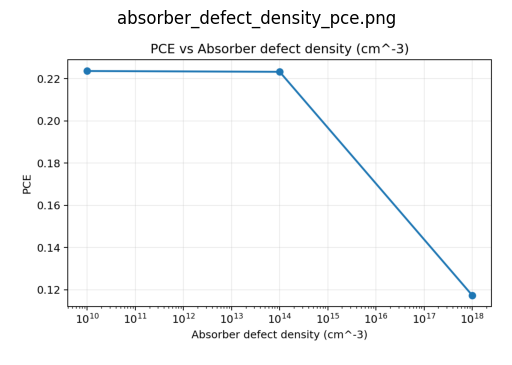

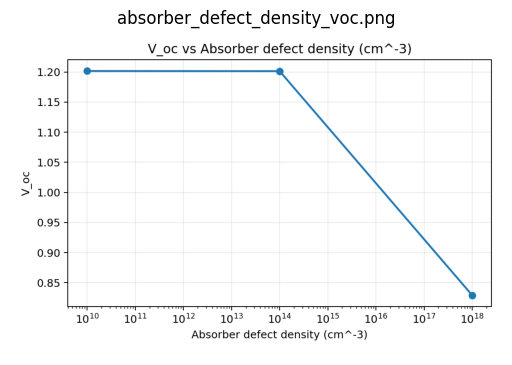

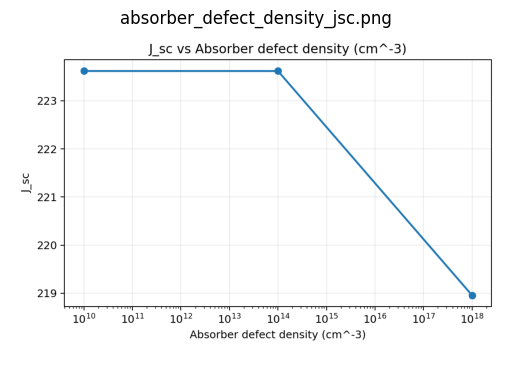

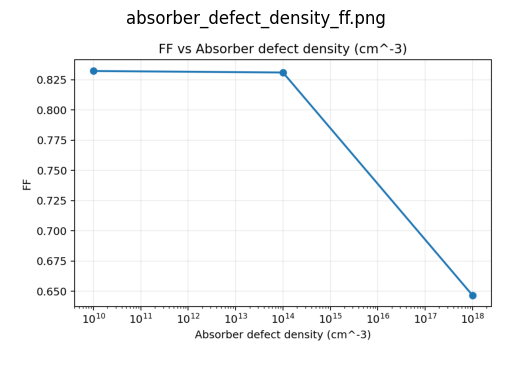

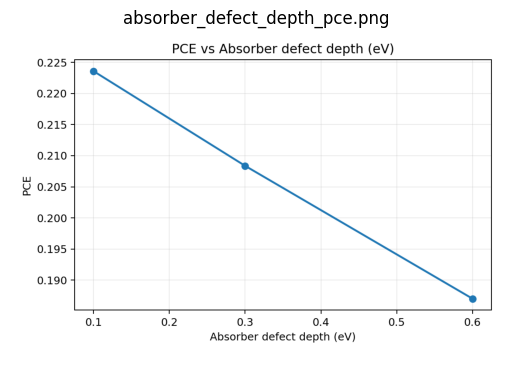

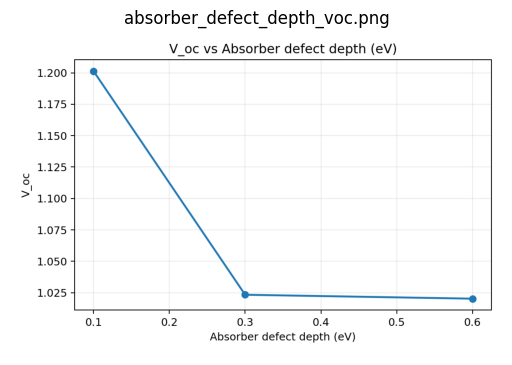

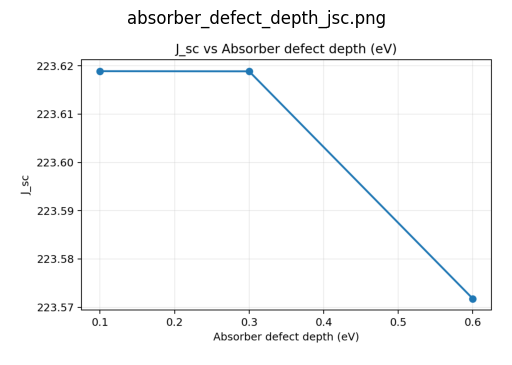

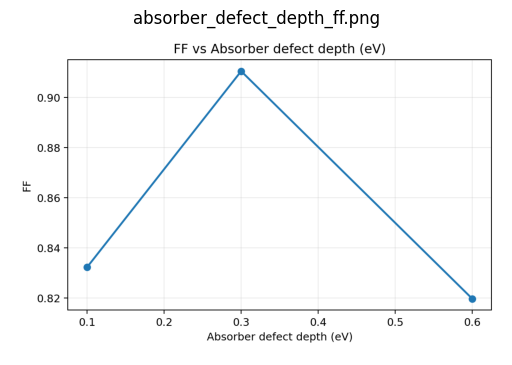

In [8]:
for path in plot_paths[:8]:
    img = plt.imread(path)
    plt.figure(figsize=(6.4, 4.2))
    plt.imshow(img)
    plt.axis("off")
    plt.title(Path(path).name)
    plt.show()


## Larger Runs

For bigger grids, prefer the CLI so the notebook stays responsive:

```bash
python scripts/run_device_parameter_sweep.py   --preset full-one-factor   --config configs/solarscale_nip_band_aligned.yaml   --out-dir outputs/device_parameter_sweep_full   --N-grid 40 --n-points 12 --plots
```
